In [1]:
!pip install -q torch scikit-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import torch.nn.functional as F

In [3]:
import json, math, random, os
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print('Imports OK')

Imports OK


## 1. Load Data

Upload  to Kaggle/Colab then set the path below.

In [4]:
TRANS_PATH = '/kaggle/input/datasets/madihaahmedchowdhury/thesis-madiha-ahmed-chowdhury/effibench_transitions.jsonl'
# If running on Colab:
# TRANS_PATH = '/content/drive/MyDrive/firecracker-rl/effibench_transitions.jsonl'

raw = []
with open(TRANS_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            raw.append(json.loads(line))

print(f'Loaded {len(raw)} transitions from {len(set(t["task_id"] for t in raw))} problems')

Loaded 7448 transitions from 532 problems


In [5]:
# ── Action configs (14 discrete resource allocations) ──────────────────────────
ACTION_CONFIGS = [
    {'cpu_millicores':  50, 'memory_limit_mb':  32, 'timeout_ms':  1000},
    {'cpu_millicores':  50, 'memory_limit_mb':  48, 'timeout_ms':  2000},
    {'cpu_millicores':  50, 'memory_limit_mb':  64, 'timeout_ms':  3000},
    {'cpu_millicores':  80, 'memory_limit_mb':  48, 'timeout_ms':  1500},
    {'cpu_millicores':  80, 'memory_limit_mb':  64, 'timeout_ms':  2500},
    {'cpu_millicores':  80, 'memory_limit_mb':  96, 'timeout_ms':  4000},
    {'cpu_millicores': 100, 'memory_limit_mb':  64, 'timeout_ms':  2000},
    {'cpu_millicores': 100, 'memory_limit_mb':  96, 'timeout_ms':  3500},
    {'cpu_millicores': 100, 'memory_limit_mb': 128, 'timeout_ms':  5000},
    {'cpu_millicores': 150, 'memory_limit_mb':  64, 'timeout_ms':  3000},
    {'cpu_millicores': 150, 'memory_limit_mb':  96, 'timeout_ms':  5000},
    {'cpu_millicores': 250, 'memory_limit_mb': 128, 'timeout_ms':  5000},
    {'cpu_millicores': 250, 'memory_limit_mb': 192, 'timeout_ms':  8000},
    {'cpu_millicores': 500, 'memory_limit_mb': 256, 'timeout_ms': 10000},
]
N_ACTIONS = len(ACTION_CONFIGS)
CPU_MAX, MEM_MAX, TO_MAX = 500, 256, 10000

def action_to_idx(action):
    key = (action['cpu_millicores'], action['memory_limit_mb'], action['timeout_ms'])
    for i, c in enumerate(ACTION_CONFIGS):
        if (c['cpu_millicores'], c['memory_limit_mb'], c['timeout_ms']) == key:
            return i
    return -1

# ── All 19 state features ───────────────────────────────────────────────────────
FEATURE_COLS = [
    'prompt_token_count',
    'prompt_complexity_score',
    'task_type',
    'has_loops_hint',
    'has_io_hint',
    'example_count',
    'line_count',
    'cyclomatic_complexity',
    'ast_node_count',
    'has_recursion',
    'has_external_calls',
    'max_loop_depth',
    'estimated_complexity',
    'host_cpu_load_1m',
    'host_mem_available_mb',
    'queue_depth',
    'recent_success_rate',
    'recent_mean_cpu_used',
    'recent_mean_mem_used',
]
N_FEATURES = len(FEATURE_COLS)
print(f'{N_ACTIONS} action configs | {N_FEATURES} state features')

14 action configs | 19 state features


In [6]:
# ── Reward recomputation (changed) ─────────────────────────
def recompute_reward(t):
    ex     = t['execution']
    action = t['action']

    r_success = 1.0 if ex['exit_code'] == 0 else -2.0
    r_timeout = -3.0 if ex['timed_out'] else 0.0

    wall_ms  = max(ex.get('wall_time_ms', 0) or 0, 1)
    wall_sec = wall_ms / 1000

    cpu_budget_ms = (action['cpu_millicores'] / 1000) * wall_sec * 1000
    cpu_used_ms   = (ex.get('cpu_user_ms', 0) or 0) + (ex.get('cpu_sys_ms', 0) or 0)
    cpu_waste     = max(0.0, (cpu_budget_ms - cpu_used_ms) / max(cpu_budget_ms, 1))

    mem_alloc_kb  = action['memory_limit_mb'] * 1024
    mem_used_kb   = ex.get('mem_peak_kb', 0) or 0
    mem_waste     = max(0.0, (mem_alloc_kb - mem_used_kb) / max(mem_alloc_kb, 1))

    r_resource    = -0.75 * cpu_waste - 0.75 * mem_waste
    r_latency     = -0.2 * math.log(wall_ms / 500 + 1)
    tests_passed  = ex.get('tests_passed')
    r_correctness = 1.0 if tests_passed is True else (-1.0 if tests_passed is False else 0.0)

    return r_timeout + r_resource + r_latency 

# ── Build DataFrame ────────────────────────────────────────────────────────────
rows = []
for t in raw:
    state = t['state']
    row = {
        'task_id':         t['task_id'],
        'action_idx':      action_to_idx(t['action']),
        'reward':          recompute_reward(t),
        'tests_passed':    t['execution']['tests_passed'],
        'exit_code':       t['execution']['exit_code'],
        'timed_out':       t['execution']['timed_out'],
        'cpu_millicores':  t['action']['cpu_millicores'],
        'memory_limit_mb': t['action']['memory_limit_mb'],
        'timeout_ms':      t['action']['timeout_ms'],
        'wall_time_ms':    t['execution'].get('wall_time_ms', 0) or 0,
        'mem_peak_kb':     t['execution'].get('mem_peak_kb', 0) or 0,
        'stress_level':    t.get('meta', {}).get('stress_level', 'unknown'),
    }
    for f in FEATURE_COLS:
        row[f] = float(state.get(f, 0) or 0)
    rows.append(row)

df = pd.DataFrame(rows)
print(f'DataFrame: {df.shape}')
print(df[FEATURE_COLS].describe().round(2))

DataFrame: (7448, 31)
       prompt_token_count  prompt_complexity_score  task_type  has_loops_hint  \
count             7448.00                  7448.00     7448.0         7448.00   
mean               594.86                     0.53        3.0            0.05   
std                401.14                     0.09        0.0            0.22   
min                 53.00                     0.11        3.0            0.00   
25%                419.00                     0.47        3.0            0.00   
50%                539.50                     0.54        3.0            0.00   
75%                690.25                     0.60        3.0            0.00   
max               6392.00                     0.86        3.0            1.00   

       has_io_hint  example_count  line_count  cyclomatic_complexity  \
count       7448.0         7448.0     7448.00                7448.00   
mean           1.0            0.0       38.49                   8.37   
std            0.0            0.

## 2. Train / Test Split

Split by **problem** (not by transition) — test set contains unseen problems.
80% train / 20% test.

In [7]:
from sklearn.model_selection import train_test_split

# get one row per problem with its stress level
problem_df = df.groupby('task_id').agg(
    stress_level=('stress_level', 'first'),
    task_type=('task_type', 'first'),
).reset_index()

print("Before split — stress distribution:")
print(problem_df['stress_level'].value_counts())

# stratify by stress_level so train and test have same proportion
# of high, medium, low stress problems
train_problems, test_problems = train_test_split(
    problem_df['task_id'].values,
    test_size=0.2,
    random_state=42,
    stratify=problem_df['stress_level'].values,
)

train_ids = set(train_problems)
test_ids  = set(test_problems)

df_train = df[df['task_id'].isin(train_ids)].reset_index(drop=True)
df_test  = df[df['task_id'].isin(test_ids)].reset_index(drop=True)

print(f'\nTrain: {len(train_ids)} problems | {len(df_train)} transitions')
print(f'Test:  {len(test_ids)}  problems | {len(df_test)}  transitions')

# confirm distributions match
train_stress = df_train.groupby('task_id')['stress_level'].first().value_counts(normalize=True)
test_stress  = df_test.groupby('task_id')['stress_level'].first().value_counts(normalize=True)
print(f'\nTrain stress distribution:\n{train_stress.round(3)}')
print(f'\nTest stress distribution:\n{test_stress.round(3)}')

print(f'\nTrain mean reward: {df_train["reward"].mean():.3f}')
print(f'Test  mean reward: {df_test["reward"].mean():.3f}')

# Normalize state features
scaler = StandardScaler()
X_train_all = scaler.fit_transform(df_train[FEATURE_COLS].values)
X_test_all  = scaler.transform(df_test[FEATURE_COLS].values)

def best_action_per_problem(df_sub):
    best = {}
    for tid, g in df_sub.groupby('task_id'):
        best[tid] = int(g.loc[g['reward'].idxmax(), 'action_idx'])
    return best

train_best = best_action_per_problem(df_train)
test_best  = best_action_per_problem(df_test)

prob_train   = df_train.drop_duplicates('task_id').reset_index(drop=True)
prob_test    = df_test.drop_duplicates('task_id').reset_index(drop=True)
X_prob_train = scaler.transform(prob_train[FEATURE_COLS].values)
X_prob_test  = scaler.transform(prob_test[FEATURE_COLS].values)
y_prob_train = np.array([train_best[t] for t in prob_train['task_id']])
y_prob_test  = np.array([test_best[t]  for t in prob_test['task_id']])

print('\nBC label distribution (train):')
print(pd.Series(y_prob_train).value_counts().sort_index())

Before split — stress distribution:
stress_level
low        210
high       133
medium     106
unknown     83
Name: count, dtype: int64

Train: 425 problems | 5950 transitions
Test:  107  problems | 1498  transitions

Train stress distribution:
stress_level
low        0.395
high       0.249
medium     0.200
unknown    0.155
Name: proportion, dtype: float64

Test stress distribution:
stress_level
low        0.393
high       0.252
medium     0.196
unknown    0.159
Name: proportion, dtype: float64

Train mean reward: -1.353
Test  mean reward: -1.351

BC label distribution (train):
0       2
3       3
4       1
5       6
6       3
7      25
9      76
10    300
11      5
13      4
Name: count, dtype: int64


## 3. Evaluation Utility

For each model: pick a config per test problem, look up its actual reward from the dataset.

In [8]:
def evaluate_policy(policy_fn, df_eval, label):
    rewards, exec_successes, oracle_matches = [], [], []

    for tid, group in df_eval.groupby('task_id'):
        state_raw  = group.iloc[0][FEATURE_COLS].values.astype(float)
        state_norm = scaler.transform(state_raw.reshape(1, -1))[0]
        pred_idx   = int(policy_fn(state_norm))
        row        = group[group['action_idx'] == pred_idx]
        if row.empty:
            continue

        r = float(row.iloc[0]['reward'])

        # success now means: code was not killed by resource limits
        # i.e. no OOM and no timeout — this is what the agent controls
        timed_out = bool(row.iloc[0]['timed_out'])
        oom       = (int(row.iloc[0]['exit_code']) == -9 and not timed_out)
        exec_ok   = 1 if (not timed_out and not oom) else 0

        oracle_idx   = int(group.loc[group['reward'].idxmax(), 'action_idx'])
        oracle_match = 1 if pred_idx == oracle_idx else 0

        rewards.append(r)
        exec_successes.append(exec_ok)
        oracle_matches.append(oracle_match)

    return {
        'model':        label,
        'avg_reward':   float(np.mean(rewards)),
        'success_rate': float(np.mean(exec_successes)),  # no OOM, no timeout
        'oracle_acc':   float(np.mean(oracle_matches)),
        'n_problems':   len(rewards),
    }

print('Evaluation utility ready.')

Evaluation utility ready.


## 4. Baselines

In [9]:
always_max_fn = lambda s: 13
always_min_fn = lambda s: 0
random_fn     = lambda s: random.randint(0, N_ACTIONS - 1)

def rule_based_fn(s):
    orig = dict(zip(FEATURE_COLS, scaler.inverse_transform(s.reshape(1, -1))[0]))
    cc   = orig['cyclomatic_complexity']
    lc   = orig['line_count']
    ld   = orig['max_loop_depth']
    ec   = orig['estimated_complexity']
    if cc > 15 or ec >= 3 or ld >= 4:
        return 11
    elif cc > 8 or lc > 50:
        return 10
    elif cc > 4 or lc > 20:
        return 7
    else:
        return 5

for name, fn in [('Always-Max', always_max_fn), ('Always-Min', always_min_fn),
                 ('Random', random_fn), ('Rule-Based', rule_based_fn)]:
    r = evaluate_policy(fn, df_test, name)
    print(f"{name:<12} | reward={r['avg_reward']:+.3f} | success={r['success_rate']:.1%} | oracle_acc={r['oracle_acc']:.1%}")

Always-Max   | reward=-0.784 | success=98.1% | oracle_acc=0.9%
Always-Min   | reward=-3.911 | success=0.9% | oracle_acc=1.9%
Random       | reward=-1.488 | success=76.6% | oracle_acc=8.4%
Rule-Based   | reward=-0.774 | success=97.2% | oracle_acc=15.9%


## 5. Behavioral Cloning (BC)

Supervised: learn to predict the best config from state features.
Label = argmax(reward) across 14 transitions per problem.

In [10]:
bc_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
)
bc_model.fit(X_prob_train, y_prob_train)

train_acc = accuracy_score(y_prob_train, bc_model.predict(X_prob_train))
test_acc  = accuracy_score(y_prob_test,  bc_model.predict(X_prob_test))
print(f'BC train accuracy: {train_acc:.3f}')
print(f'BC test  accuracy: {test_acc:.3f}')

bc_policy_fn = lambda s: int(bc_model.predict(s.reshape(1, -1))[0])
r = evaluate_policy(bc_policy_fn, df_test, 'BC')
print(f'BC | reward={r['avg_reward']:+.3f} | success={r['success_rate']:.1%} | oracle_acc={r['oracle_acc']:.1%}')

BC train accuracy: 0.706
BC test  accuracy: 0.766
BC | reward=-0.722 | success=98.1% | oracle_acc=76.6%


# Device CUDA

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 6. CQL — Conservative Q-Learning (Discrete)

Offline RL: Q-network over 14 discrete actions.
Single-step MDP (done=True always) → target = r (no bootstrapping).
CQL penalty prevents overestimating unseen actions.

# Best CQL

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CQL FINAL — alpha=0.1, deeper network, cosine LR, AdamW, stratified data
# All fixes applied:
#   - CosineAnnealingLR so lr actually decays
#   - AdamW for better weight decay
#   - best_state saving (returns best weights not final weights)
#   - patience=100 so early stopping is not too aggressive
#   - trains on ALL transitions (not just best-per-problem) with reward signal
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

BEST_ALPHA = 0.1
N_EPOCHS   = 1500
BATCH_SIZE = 512
LR         = 3e-4

# ── Network definitions ───────────────────────────────────────────────────────

class QNetworkDeep(nn.Module):
    """256 → 256 → 128 → n_actions with dropout."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(128, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class DuelingQNetworkDeep(nn.Module):
    """Deeper dueling network — separates V(s) from A(s,a)."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        feat = self.feature(x)
        v    = self.value(feat)
        a    = self.advantage(feat)
        return v + (a - a.mean(dim=1, keepdim=True))


# ── Data prep — ALL transitions, not just best-per-problem ───────────────────
X_cql_f = scaler.transform(df_train[FEATURE_COLS].values)
a_cql_f = df_train['action_idx'].values.astype(int)
r_cql_f = df_train['reward'].values.astype(np.float32)

Xf = torch.FloatTensor(X_cql_f).to(device)
af = torch.LongTensor(a_cql_f).to(device)
rf = torch.FloatTensor(r_cql_f).to(device)

loader_final = DataLoader(
    TensorDataset(Xf, af, rf),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# ── Training function — all fixes applied ────────────────────────────────────
def train_final_cql(net, label):
    net = net.to(device)

    # AdamW — better weight decay than Adam
    opt = optim.AdamW(net.parameters(), lr=LR, weight_decay=1e-4)

    # CosineAnnealingLR — decays lr smoothly from LR to 1e-6
    # unlike ReduceLROnPlateau this ALWAYS decays so lr reaches small values
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=N_EPOCHS, eta_min=1e-6
    )

    best_loss  = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(N_EPOCHS):
        net.train()
        total_loss = 0

        for xb, ab, rb in loader_final:
            q_all   = net(xb)
            q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)

            # Huber loss — robust to the extreme -7.x timeout rewards
            bellman = F.smooth_l1_loss(q_taken, rb)

            # CQL penalty — pushes down Q-values for unseen actions
            cql_pen = (torch.logsumexp(q_all, dim=1)
                       - q_taken).mean()

            loss = bellman + BEST_ALPHA * cql_pen
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader_final)
        scheduler.step()   # cosine: step every epoch, no condition

        # save best weights so we return best model not just final
        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= 100:
                print(f'  [{label}] early stop epoch {epoch+1} '                      f'| best={best_loss:.4f}')
                break

        if (epoch + 1) % 200 == 0:
            print(f'  [{label}] epoch {epoch+1}/{N_EPOCHS} '                  f'| loss={avg_loss:.4f} '                  f'| lr={opt.param_groups[0]["lr"]:.2e}')

    if best_state is not None:
        net.load_state_dict(best_state)
    net.eval()
    return net


# ── Train 1: Standard deep CQL ───────────────────────────────────────────────
print(f'Training CQL standard (alpha={BEST_ALPHA})...')
cql_std_net = QNetworkDeep(N_FEATURES, N_ACTIONS)
cql_std_net = train_final_cql(cql_std_net, 'CQL std')

def cql_std_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        return int(cql_std_net(t).argmax().item())

r_cql_std = evaluate_policy(cql_std_policy_fn, df_test, 'CQL_standard')
print(f'  std  | reward={r_cql_std["avg_reward"]:+.3f} '      f'| success={r_cql_std["success_rate"]:.1%} '      f'| oracle={r_cql_std["oracle_acc"]:.1%}')


# ── Train 2: Dueling deep CQL ────────────────────────────────────────────────
print(f'\nTraining CQL dueling (alpha={BEST_ALPHA})...')
cql_duel_net = DuelingQNetworkDeep(N_FEATURES, N_ACTIONS)
cql_duel_net = train_final_cql(cql_duel_net, 'CQL duel')

def cql_duel_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        return int(cql_duel_net(t).argmax().item())

r_cql_duel = evaluate_policy(cql_duel_policy_fn, df_test, 'CQL_dueling')
print(f'  duel | reward={r_cql_duel["avg_reward"]:+.3f} '      f'| success={r_cql_duel["success_rate"]:.1%} '      f'| oracle={r_cql_duel["oracle_acc"]:.1%}')


# ── Train 3: Ensemble deep CQL ────────────────────────────────────────────────
print(f'\nTraining CQL ensemble (alpha={BEST_ALPHA}, 3 seeds)...')
ensemble_nets_final = []
for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    enet = QNetworkDeep(N_FEATURES, N_ACTIONS)
    enet = train_final_cql(enet, f'CQL ens s={seed}')
    ensemble_nets_final.append(enet)
    print(f'  seed {seed} done')

def cql_ens_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        q_min = torch.stack([n(t) for n in ensemble_nets_final]).min(dim=0).values
    return int(q_min.argmax().item())

r_cql_ens = evaluate_policy(cql_ens_policy_fn, df_test, 'CQL_ensemble')
print(f'  ens  | reward={r_cql_ens["avg_reward"]:+.3f} '      f'| success={r_cql_ens["success_rate"]:.1%} '      f'| oracle={r_cql_ens["oracle_acc"]:.1%}')


# ── Results ───────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print(f'  CQL variants — alpha={BEST_ALPHA}, stratified split, no r_correctness')
print('='*60)
print(f'{"Model":<24} {"Reward":>9} {"Success":>9} {"Oracle":>9}')
print('-'*60)
for label, r in [('CQL standard',  r_cql_std),
                  ('CQL dueling',   r_cql_duel),
                  ('CQL ensemble',  r_cql_ens)]:
    print(f'{label:<24} {r["avg_reward"]:>+9.3f} {r["success_rate"]:>9.1%} {r["oracle_acc"]:>9.1%}')
print('='*60)


# ── Set best CQL for downstream use ──────────────────────────────────────────
_cands = [
    (r_cql_std["avg_reward"],  'standard',  cql_std_policy_fn,  cql_std_net),
    (r_cql_duel["avg_reward"], 'dueling',   cql_duel_policy_fn, cql_duel_net),
    (r_cql_ens["avg_reward"],  'ensemble',  cql_ens_policy_fn,  ensemble_nets_final[0]),
]
best_r, best_name, cql_policy_fn, cql_net = max(_cands, key=lambda x: x[0])
print(f'\nBest CQL: {best_name} (reward={best_r:+.3f})')
print('cql_policy_fn ready for comparison table.')


Training CQL standard (alpha=0.1)...
  [CQL std] epoch 200/1500 | loss=0.4107 | lr=2.87e-04
  [CQL std] epoch 400/1500 | loss=0.3864 | lr=2.51e-04
  [CQL std] epoch 600/1500 | loss=0.3750 | lr=1.97e-04
  [CQL std] epoch 800/1500 | loss=0.3691 | lr=1.35e-04
  [CQL std] epoch 1000/1500 | loss=0.3574 | lr=7.58e-05
  [CQL std] early stop epoch 1130 | best=0.3557
  std  | reward=-0.818 | success=95.3% | oracle=66.4%

Training CQL dueling (alpha=0.1)...
  [CQL duel] epoch 200/1500 | loss=0.4030 | lr=2.87e-04
  [CQL duel] epoch 400/1500 | loss=0.3738 | lr=2.51e-04
  [CQL duel] epoch 600/1500 | loss=0.3522 | lr=1.97e-04
  [CQL duel] epoch 800/1500 | loss=0.3396 | lr=1.35e-04
  [CQL duel] epoch 1000/1500 | loss=0.3356 | lr=7.58e-05
  [CQL duel] epoch 1200/1500 | loss=0.3309 | lr=2.96e-05
  [CQL duel] early stop epoch 1236 | best=0.3306
  duel | reward=-0.851 | success=94.4% | oracle=47.7%

Training CQL ensemble (alpha=0.1, 3 seeds)...
  [CQL ens s=42] epoch 200/1500 | loss=0.4107 | lr=2.87e-04


# IQL

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# IQL — Implicit Q-Learning
# More stable than CQL for offline RL — never queries unseen actions
# Uses expectile regression on V(s) instead of max Q bootstrap
# ══════════════════════════════════════════════════════════════════════════════

IQL_TAU    = 0.7    # expectile parameter — 0.7 is standard default
IQL_EPOCHS = 1500
IQL_LR     = 3e-4

# ── Value network V(s) ────────────────────────────────────────────────────────
# estimates how good a state is regardless of which action is taken
# separate from the Q-network which estimates per-action value

class ValueNet(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# ── Expectile loss ─────────────────────────────────────────────────────────────
# asymmetric squared loss — penalises underestimation more than overestimation
# tau=0.7 means we are slightly optimistic about state values
# this is the core difference from CQL — no OOD action queries at all

def expectile_loss(diff, tau=0.7):
    weight = torch.where(diff > 0,
                         torch.full_like(diff, tau),
                         torch.full_like(diff, 1 - tau))
    return (weight * diff.pow(2)).mean()

# ── Data — reuse from cell 25 ─────────────────────────────────────────────────
# Xf, af, rf, loader_final already defined in cell 25
# if cell 25 used different variable names check and align

iql_q_net = QNetworkDeep(N_FEATURES, N_ACTIONS).to(device)
iql_v_net = ValueNet(N_FEATURES).to(device)

# initial v and q(better, that's why reverted to this one )
q_opt = optim.AdamW(iql_q_net.parameters(), lr=IQL_LR, weight_decay=1e-4)
v_opt = optim.AdamW(iql_v_net.parameters(), lr=IQL_LR, weight_decay=1e-4)

# changed v and q -bad
# V-network learns slower — it estimates state values which are harder to pin down
# v_opt = optim.AdamW(iql_v_net.parameters(), lr=1e-4, weight_decay=1e-4)

# # Q-network learns faster — it just needs to match rewards
# q_opt = optim.AdamW(iql_q_net.parameters(), lr=3e-4, weight_decay=1e-4)

# cosine annealing so lr actually decays instead of waiting for plateau
q_sch = optim.lr_scheduler.CosineAnnealingLR(
    q_opt, T_max=IQL_EPOCHS, eta_min=1e-6
)
v_sch = optim.lr_scheduler.CosineAnnealingLR(
    v_opt, T_max=IQL_EPOCHS, eta_min=1e-6
)

best_iql_loss  = float('inf')
best_iql_state = None
no_improve_iql = 0

print('Training IQL...')
print(f'  tau={IQL_TAU} | epochs={IQL_EPOCHS} | lr={IQL_LR}')

for epoch in range(IQL_EPOCHS):
    iql_q_net.train()
    iql_v_net.train()
    total_loss = 0

    for xb, ab, rb in loader_final:

        # ── Step 1: update value network V(s) ─────────────────────────────────
        # V(s) learns to predict the reward using expectile regression
        # this never touches Q(s,a) for actions outside the dataset
        v_pred = iql_v_net(xb)
        v_loss = expectile_loss(rb - v_pred, tau=IQL_TAU)

        v_opt.zero_grad()
        v_loss.backward()
        torch.nn.utils.clip_grad_norm_(iql_v_net.parameters(), 1.0)
        v_opt.step()

        # ── Step 2: update Q network Q(s,a) ──────────────────────────────────
        # Q(s,a) learns to predict reward for the actions we actually took
        # target uses V(s) not max Q(s,a') so no OOD action evaluation
        q_all   = iql_q_net(xb)
        q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)
        q_loss  = F.smooth_l1_loss(q_taken, rb)

        q_opt.zero_grad()
        q_loss.backward()
        torch.nn.utils.clip_grad_norm_(iql_q_net.parameters(), 1.0)
        q_opt.step()

        total_loss += (v_loss.item() + q_loss.item())

    # step both schedulers every epoch
    q_sch.step()
    v_sch.step()

    avg_loss = total_loss / len(loader_final)

    # save best weights
    if avg_loss < best_iql_loss - 1e-4:
        best_iql_loss  = avg_loss
        no_improve_iql = 0
        best_iql_state = {k: v.clone()
                          for k, v in iql_q_net.state_dict().items()}
    else:
        no_improve_iql += 1
        if no_improve_iql >= 100:
            print(f'  [IQL] early stop at epoch {epoch+1} '
                  f'| best_loss={best_iql_loss:.4f}')
            break

    if (epoch + 1) % 300 == 0:
        print(f'  [IQL] epoch {epoch+1}/{IQL_EPOCHS} '
              f'| loss={avg_loss:.4f} '
              f'| lr={q_opt.param_groups[0]["lr"]:.2e}')

# restore best weights
if best_iql_state is not None:
    iql_q_net.load_state_dict(best_iql_state)
iql_q_net.eval()

# ── Policy function ───────────────────────────────────────────────────────────
def iql_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        return int(iql_q_net(t).argmax().item())

r_iql = evaluate_policy(iql_policy_fn, df_test, 'IQL')
print(f'\nIQL | reward={r_iql["avg_reward"]:+.3f} '
      f'| success={r_iql["success_rate"]:.1%} '
      f'| oracle={r_iql["oracle_acc"]:.1%}')

Training IQL...
  tau=0.7 | epochs=1500 | lr=0.0003
  [IQL] epoch 300/1500 | loss=0.6071 | lr=2.71e-04
  [IQL] epoch 600/1500 | loss=0.5750 | lr=1.97e-04
  [IQL] epoch 900/1500 | loss=0.5682 | lr=1.04e-04
  [IQL] epoch 1200/1500 | loss=0.5612 | lr=2.96e-05
  [IQL] early stop at epoch 1282 | best_loss=0.5554

IQL | reward=-0.884 | success=93.5% | oracle=57.0%


# just weighted inference

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# IQL VARIANT 1 — Weighted inference (no retraining needed)
# Instead of argmax Q, use softmax over advantage with temperature
# Low temperature = nearly greedy, high temperature = more exploratory
# ══════════════════════════════════════════════════════════════════════════════

iql_q_net.eval()
iql_v_net.eval()

variant1_results = []

for temperature in [0.1, 0.3, 0.5, 1.0]:

    def _iql_weighted(s, temp=temperature):
        with torch.no_grad():
            t   = torch.FloatTensor(s).unsqueeze(0).to(device)
            q   = iql_q_net(t)
            v   = iql_v_net(t).unsqueeze(1)
            adv = q - v
            probs = F.softmax(adv / temp, dim=1)
        return int(torch.multinomial(probs, 1).item())

    r = evaluate_policy(_iql_weighted, df_test, f'IQL_weighted_t={temperature}')
    variant1_results.append((temperature, r))
    print(f'  temp={temperature} | reward={r["avg_reward"]:+.3f} '
          f'| success={r["success_rate"]:.1%} '
          f'| oracle={r["oracle_acc"]:.1%}')

best_temp, best_v1_r = max(variant1_results, key=lambda x: x[1]['avg_reward'])
print(f'\nBest temperature: {best_temp} '
      f'(reward={best_v1_r["avg_reward"]:+.3f} '
      f'oracle={best_v1_r["oracle_acc"]:.1%})')

# set best weighted policy for downstream use
def iql_weighted_policy_fn(s):
    with torch.no_grad():
        t   = torch.FloatTensor(s).unsqueeze(0).to(device)
        q   = iql_q_net(t)
        v   = iql_v_net(t).unsqueeze(1)
        adv = q - v
        probs = F.softmax(adv / best_temp, dim=1)
    return int(torch.multinomial(probs, 1).item())

  temp=0.1 | reward=-0.944 | success=92.5% | oracle=7.5%
  temp=0.3 | reward=-0.770 | success=98.1% | oracle=14.0%
  temp=0.5 | reward=-0.797 | success=97.2% | oracle=12.1%
  temp=1.0 | reward=-0.891 | success=95.3% | oracle=8.4%

Best temperature: 0.3 (reward=-0.770 oracle=14.0%)


# IQL + BC 

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# IQL VARIANT 2 — Blend IQL Q-values with BC class probabilities (no retraining)
# Combines IQL reward landscape knowledge with BC's direct best-action knowledge
# alpha=1.0 = pure IQL, alpha=0.0 = pure BC
# ══════════════════════════════════════════════════════════════════════════════

iql_q_net.eval()

def blended_policy_fn(s, alpha=0.5):
    # IQL Q-values as probabilities
    with torch.no_grad():
        t      = torch.FloatTensor(s).unsqueeze(0).to(device)
        q_vals = F.softmax(iql_q_net(t), dim=1).cpu().numpy()[0]

    # BC class probabilities
    bc_probs_raw = bc_model.predict_proba(s.reshape(1, -1))[0]

    # BC may not have seen all 14 classes — pad to N_ACTIONS
    bc_probs = np.zeros(N_ACTIONS)
    for i, cls in enumerate(bc_model.classes_):
        bc_probs[int(cls)] = bc_probs_raw[i]

    # blend
    blended = alpha * q_vals + (1 - alpha) * bc_probs
    return int(np.argmax(blended))

variant2_results = []

for alpha in [0.2, 0.3, 0.5, 0.7, 0.8]:

    def _blended(s, a=alpha):
        return blended_policy_fn(s, alpha=a)

    r = evaluate_policy(_blended, df_test, f'IQL+BC_alpha={alpha}')
    variant2_results.append((alpha, r))
    print(f'  alpha={alpha} | reward={r["avg_reward"]:+.3f} '
          f'| success={r["success_rate"]:.1%} '
          f'| oracle={r["oracle_acc"]:.1%}')

best_alpha, best_v2_r = max(variant2_results, key=lambda x: x[1]['avg_reward'])
print(f'\nBest alpha: {best_alpha} '
      f'(reward={best_v2_r["avg_reward"]:+.3f} '
      f'oracle={best_v2_r["oracle_acc"]:.1%})')

# set best blended policy for downstream use
def iql_bc_blended_policy_fn(s):
    return blended_policy_fn(s, alpha=best_alpha)

  alpha=0.2 | reward=-0.722 | success=98.1% | oracle=76.6%
  alpha=0.3 | reward=-0.722 | success=98.1% | oracle=76.6%
  alpha=0.5 | reward=-0.722 | success=98.1% | oracle=76.6%
  alpha=0.7 | reward=-0.751 | success=97.2% | oracle=76.6%
  alpha=0.8 | reward=-0.751 | success=97.2% | oracle=76.6%

Best alpha: 0.2 (reward=-0.722 oracle=76.6%)


# IQL ensemble with mean Q

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# IQL VARIANT 4 — Ensemble with mean Q (not min like CQL ensemble)
# IQL is already conservative so mean is better than pessimistic min
# Trains 3 networks with different seeds and averages their Q-values
# ══════════════════════════════════════════════════════════════════════════════

iql_ensemble_nets = []

for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    print(f'\nTraining IQL ensemble seed={seed}...')

    q_e = QNetworkDeep(N_FEATURES, N_ACTIONS).to(device)
    v_e = ValueNet(N_FEATURES).to(device)

    q_opt_e = optim.AdamW(q_e.parameters(), lr=3e-4, weight_decay=1e-4)
    v_opt_e = optim.AdamW(v_e.parameters(), lr=1e-4, weight_decay=1e-4)
    q_sch_e = optim.lr_scheduler.CosineAnnealingLR(q_opt_e, T_max=1500, eta_min=1e-6)
    v_sch_e = optim.lr_scheduler.CosineAnnealingLR(v_opt_e, T_max=1500, eta_min=1e-6)

    best_loss_e  = float('inf')
    best_state_e = None
    no_improve_e = 0

    for epoch in range(1500):
        q_e.train(); v_e.train()
        total = 0

        for xb, ab, rb in loader_final:
            # value update
            v_pred = v_e(xb)
            v_loss = expectile_loss(rb - v_pred, tau=0.7)
            v_opt_e.zero_grad()
            v_loss.backward()
            torch.nn.utils.clip_grad_norm_(v_e.parameters(), 1.0)
            v_opt_e.step()

            # Q update
            q_all   = q_e(xb)
            q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)
            q_loss  = F.smooth_l1_loss(q_taken, rb)
            q_opt_e.zero_grad()
            q_loss.backward()
            torch.nn.utils.clip_grad_norm_(q_e.parameters(), 1.0)
            q_opt_e.step()

            total += (v_loss.item() + q_loss.item())

        q_sch_e.step(); v_sch_e.step()
        avg = total / len(loader_final)

        if avg < best_loss_e - 1e-4:
            best_loss_e  = avg
            no_improve_e = 0
            best_state_e = {k: v.clone() for k, v in q_e.state_dict().items()}
        else:
            no_improve_e += 1
            if no_improve_e >= 100:
                print(f'  [IQL ens s={seed}] early stop epoch {epoch+1}')
                break

        if (epoch + 1) % 300 == 0:
            print(f'  [IQL ens s={seed}] epoch {epoch+1}/1500 '
                  f'| loss={avg:.4f}')

    if best_state_e:
        q_e.load_state_dict(best_state_e)
    q_e.eval()
    iql_ensemble_nets.append(q_e)

# ── Mean ensemble policy ──────────────────────────────────────────────────────
def iql_ens_mean_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        q_mean = torch.stack([n(t) for n in iql_ensemble_nets]).mean(dim=0)
    return int(q_mean.argmax().item())

# ── Min ensemble policy (pessimistic) ────────────────────────────────────────
def iql_ens_min_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        q_min = torch.stack([n(t) for n in iql_ensemble_nets]).min(dim=0).values
    return int(q_min.argmax().item())

r_ens_mean = evaluate_policy(iql_ens_mean_policy_fn, df_test, 'IQL_ens_mean')
r_ens_min  = evaluate_policy(iql_ens_min_policy_fn,  df_test, 'IQL_ens_min')

print(f'\nIQL ensemble mean | reward={r_ens_mean["avg_reward"]:+.3f} '
      f'| success={r_ens_mean["success_rate"]:.1%} '
      f'| oracle={r_ens_mean["oracle_acc"]:.1%}')
print(f'IQL ensemble min  | reward={r_ens_min["avg_reward"]:+.3f} '
      f'| success={r_ens_min["success_rate"]:.1%} '
      f'| oracle={r_ens_min["oracle_acc"]:.1%}')

# pick best ensemble variant
if r_ens_mean['avg_reward'] >= r_ens_min['avg_reward']:
    iql_ensemble_policy_fn = iql_ens_mean_policy_fn
    print('\nUsing mean ensemble as final IQL ensemble policy')
else:
    iql_ensemble_policy_fn = iql_ens_min_policy_fn
    print('\nUsing min ensemble as final IQL ensemble policy')


Training IQL ensemble seed=42...
  [IQL ens s=42] epoch 300/1500 | loss=0.6222
  [IQL ens s=42] epoch 600/1500 | loss=0.5811
  [IQL ens s=42] epoch 900/1500 | loss=0.5731
  [IQL ens s=42] early stop epoch 1149

Training IQL ensemble seed=123...
  [IQL ens s=123] epoch 300/1500 | loss=0.6241
  [IQL ens s=123] epoch 600/1500 | loss=0.5838
  [IQL ens s=123] epoch 900/1500 | loss=0.5699
  [IQL ens s=123] early stop epoch 1196

Training IQL ensemble seed=777...
  [IQL ens s=777] epoch 300/1500 | loss=0.6197
  [IQL ens s=777] epoch 600/1500 | loss=0.5826
  [IQL ens s=777] epoch 900/1500 | loss=0.5700
  [IQL ens s=777] early stop epoch 1098

IQL ensemble mean | reward=-0.847 | success=94.4% | oracle=71.0%
IQL ensemble min  | reward=-0.753 | success=97.2% | oracle=71.0%

Using min ensemble as final IQL ensemble policy


## 7. Full Comparison

In [17]:
# ── Full model comparison ─────────────────────────────────────────────────────
all_models = [
    ('Always-Max',       always_max_fn),
    ('Always-Min',       always_min_fn),
    ('Random',           random_fn),
    ('Rule-Based',       rule_based_fn),
    ('BC',               bc_policy_fn),
    ('CQL (best)',       cql_policy_fn),
    ('IQL',              iql_policy_fn),
    ('IQL ensemble',     iql_ensemble_policy_fn),
    ('IQL + BC blend',   iql_bc_blended_policy_fn),
]
results = [evaluate_policy(fn, df_test, name) for name, fn in all_models]
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df[['avg_reward', 'success_rate', 'oracle_acc', 'n_problems']]
results_df.columns = ['Avg Reward', 'Success Rate', 'Oracle Acc', 'N Problems']

print(results_df.sort_values('Avg Reward', ascending=False).round(3).to_string())


                Avg Reward  Success Rate  Oracle Acc  N Problems
model                                                           
BC                  -0.722         0.981       0.766         107
IQL + BC blend      -0.722         0.981       0.766         107
IQL ensemble        -0.753         0.972       0.710         107
Rule-Based          -0.774         0.972       0.159         107
CQL (best)          -0.784         0.963       0.692         107
Always-Max          -0.784         0.981       0.009         107
IQL                 -0.884         0.935       0.570         107
Random              -1.325         0.813       0.112         107
Always-Min          -3.911         0.009       0.019         107


## 8. Plots

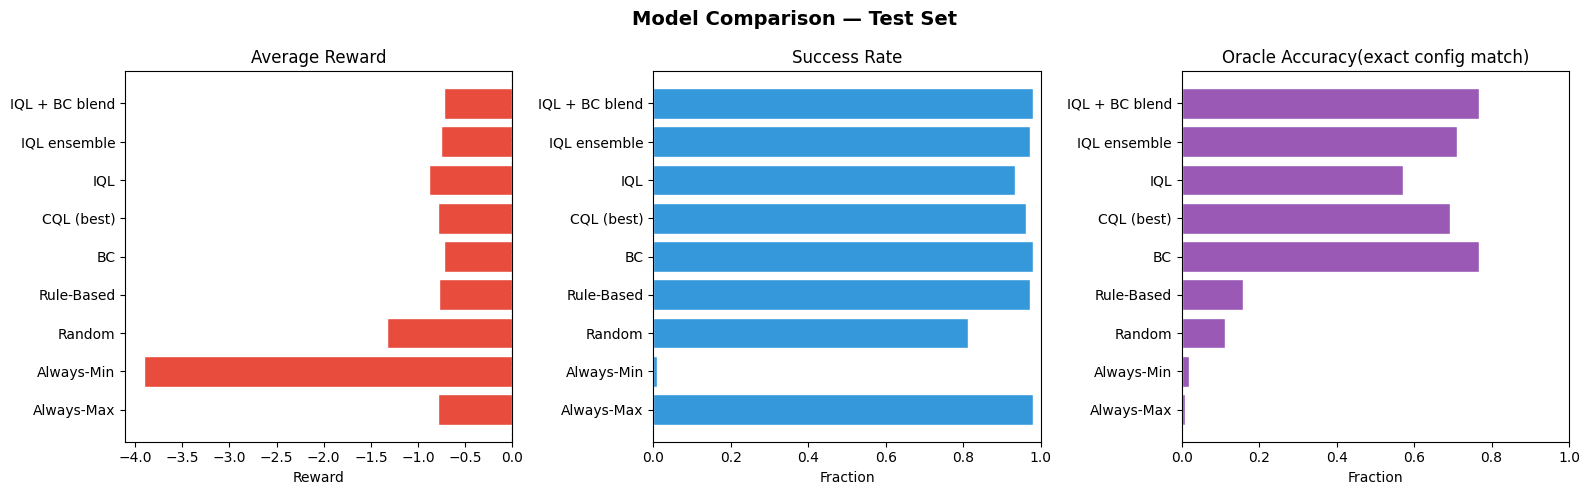

In [18]:
models     = results_df.index.tolist()
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in results_df['Avg Reward']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Test Set', fontsize=14, fontweight='bold')

axes[0].barh(models, results_df['Avg Reward'], color=colors_bar, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Average Reward')
axes[0].set_xlabel('Reward')

axes[1].barh(models, results_df['Success Rate'], color='#3498db', edgecolor='white')
axes[1].set_title('Success Rate')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Fraction')

axes[2].barh(models, results_df['Oracle Acc'], color='#9b59b6', edgecolor='white')
axes[2].set_title('Oracle Accuracy(exact config match)')
axes[2].set_xlim(0, 1)
axes[2].set_xlabel('Fraction')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

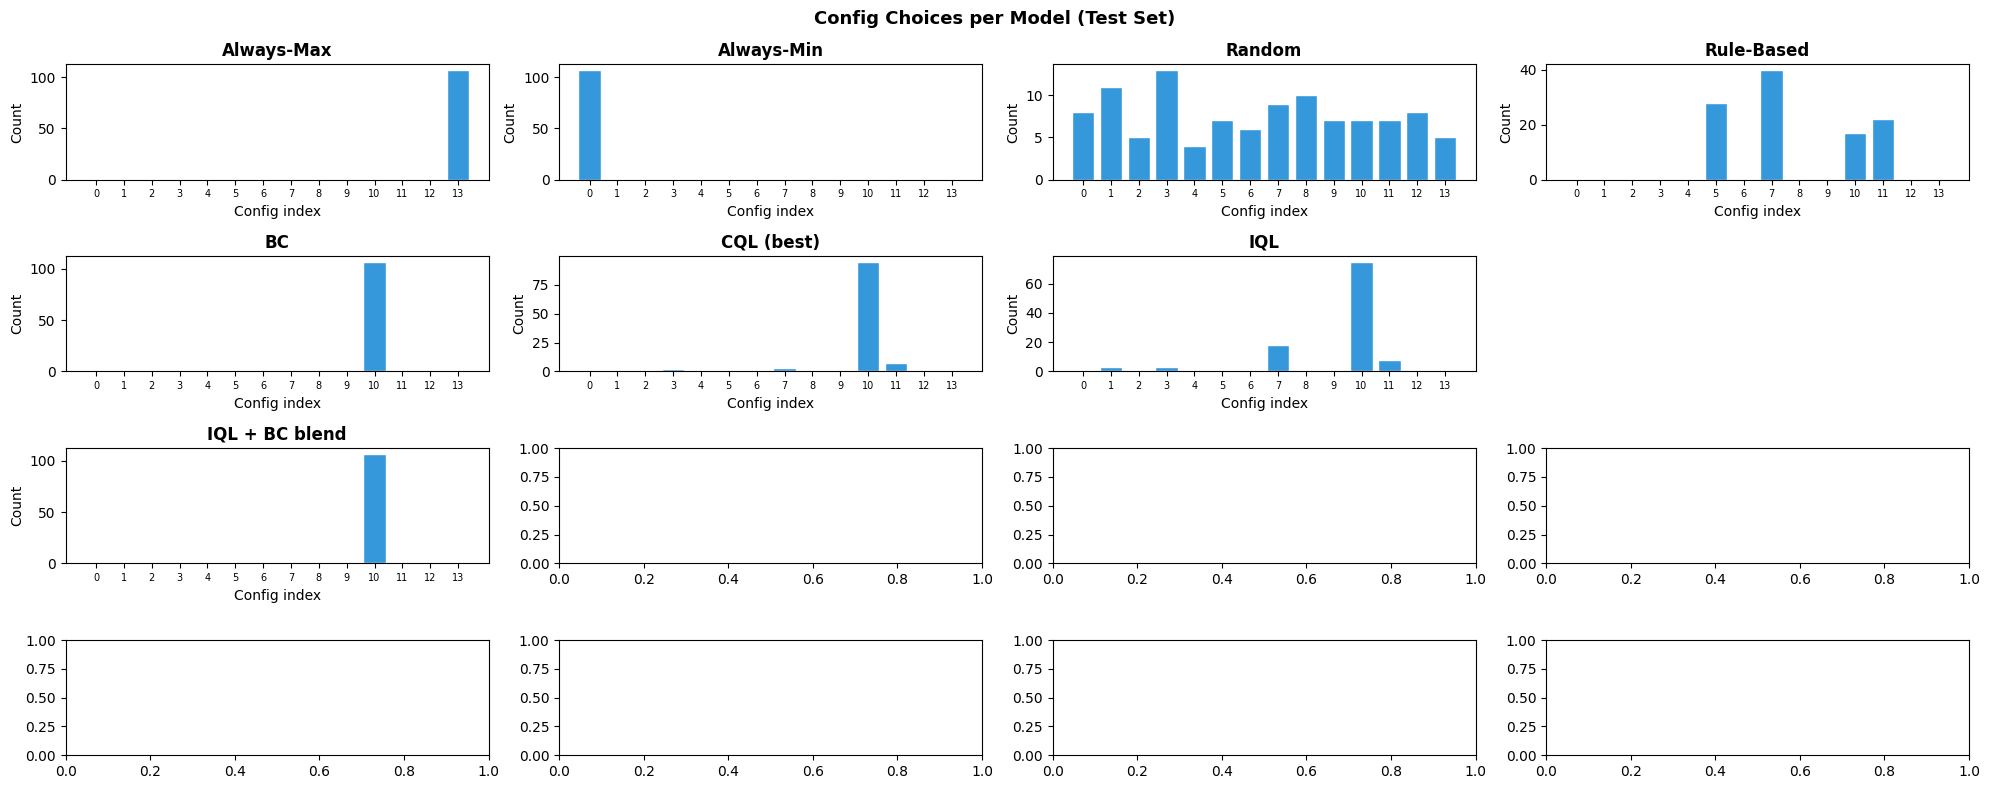

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(20, 8))  # 2×4 = 8 slots, enough for 7
axes = axes.flatten()

for i, (name, fn) in enumerate(all_models):
    counts = defaultdict(int)
    for tid, group in df_test.groupby('task_id'):
        s = scaler.transform(group.iloc[0][FEATURE_COLS].values.reshape(1, -1))[0]
        counts[fn(s)] += 1
    vals = [counts.get(j, 0) for j in range(N_ACTIONS)]
    axes[i].bar(range(N_ACTIONS), vals, color='#3498db', edgecolor='white')
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xticks(range(N_ACTIONS))
    axes[i].set_xticklabels([str(j) for j in range(N_ACTIONS)], fontsize=7)
    axes[i].set_xlabel('Config index')
    axes[i].set_ylabel('Count')

# hide the empty 8th subplot
axes[7].set_visible(False)

plt.suptitle('Config Choices per Model (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('config_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

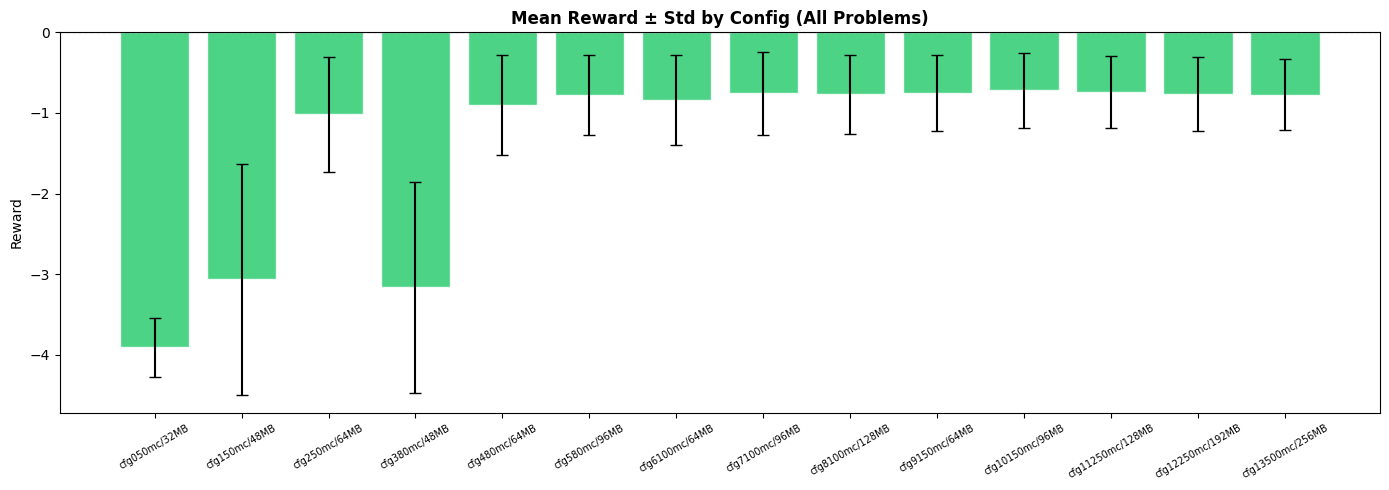

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
df_grouped = df.groupby('action_idx')['reward'].agg(['mean', 'std']).reset_index()
ax.bar(df_grouped['action_idx'], df_grouped['mean'],
       yerr=df_grouped['std'], capsize=4, color='#2ecc71', edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(N_ACTIONS))
ax.set_xticklabels([f"cfg{i}{c['cpu_millicores']}mc/{c['memory_limit_mb']}MB"
                    for i, c in enumerate(ACTION_CONFIGS)], fontsize=7, rotation=30)
ax.set_title('Mean Reward ± Std by Config (All Problems)', fontweight='bold')
ax.set_ylabel('Reward')
plt.tight_layout()
plt.savefig('reward_by_config.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
results_df.to_csv('model_results.csv')
print('Saved model_results.csv')
print('Final results:')
print(results_df.sort_values('Avg Reward', ascending=True).round(3).to_string())

Saved model_results.csv
Final results:
                Avg Reward  Success Rate  Oracle Acc  N Problems
model                                                           
Always-Min          -3.911         0.009       0.019         107
Random              -1.325         0.813       0.112         107
IQL                 -0.884         0.935       0.570         107
Always-Max          -0.784         0.981       0.009         107
CQL (best)          -0.784         0.963       0.692         107
Rule-Based          -0.774         0.972       0.159         107
IQL ensemble        -0.753         0.972       0.710         107
BC                  -0.722         0.981       0.766         107
IQL + BC blend      -0.722         0.981       0.766         107
